In [1]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

import yfinance as yf
import matplotlib.pyplot as plt

In [2]:


SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

TICKER = "AAPL"
START = "2018-01-01"
END = None

TRAIN_FRAC = 0.8

# Trading / reward parameters
FEE = 0.0005         # transaction cost per unit position change
KAPPA = 0.1          # risk penalty weight
INITIAL_BUDGET = 100000.0  # Starting capital

# PPO hyperparameters (good starting point for toy project)
num_envs = 16
n_steps = 128
total_updates = 2000

gamma = 0.99
gae_lambda = 0.95

lr = 3e-4
vf_coef = 0.5
ent_coef = 0.001
max_grad_norm = 0.5

clip_eps = 0.2
ppo_epochs = 10
minibatch_size = 64
target_kl = 0.1

In [3]:
def load_ohlcv(ticker, start, end=None, interval="1d"):
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    df = df.dropna()

    # --- FIX MULTIINDEX ---
    if isinstance(df.columns, pd.MultiIndex):
        # keep only price level (drop ticker level)
        df.columns = df.columns.get_level_values(0)

    df.columns = [c.lower() for c in df.columns]

    return df

df = load_ohlcv(TICKER, START, END)
df.head()

,close,high,low,open,volume
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297150,40.839968,40.233980,40.367342,118071600
2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200


# Feature engineering + toy forecasting features

In [4]:
def add_features_and_forecast(df, ewma_span=20, vol_window=20):
    df = df.copy()
    df["log_close"] = np.log(df["close"])
    df["r"] = df["log_close"].diff()

    # Forecast signal (toy): EWMA mean of returns
    df["mu_hat"] = df["r"].ewm(span=ewma_span, adjust=False).mean()

    # Risk estimate: rolling volatility
    df["sigma_hat"] = df["r"].rolling(vol_window).std()

    # Lag features
    df["r_lag1"] = df["r"].shift(1)

    df = df.dropna()
    return df

df_feat = add_features_and_forecast(df)
df_feat.head()

,close,high,low,open,volume,log_close,r,mu_hat,sigma_hat,r_lag1
Date,,,,,,,,,,
2018-01-31,39.174088,39.410402,38.956494,39.043063,129915600,3.668015,0.002751,-0.003306,0.009490,-0.005912
2018-02-01,39.255985,39.452522,39.017332,39.113262,188923200,3.670104,0.002088,-0.002792,0.009519,0.002751
2018-02-02,37.552662,39.026692,37.459074,38.839513,346375200,3.625744,-0.044360,-0.006751,0.013416,0.002088
2018-02-05,36.614422,38.343482,36.499774,37.225091,290954000,3.600442,-0.025302,-0.008518,0.013745,-0.044360
2018-02-06,38.144608,38.306049,36.031832,36.226030,272975200,3.641384,0.040942,-0.003807,0.017246,-0.025302


# Train/Test split (time-based)

In [5]:
n = len(df_feat)
split = int(TRAIN_FRAC * n)

df_train = df_feat.iloc[:split].reset_index(drop=True)
df_test  = df_feat.iloc[split:].reset_index(drop=True)

print(len(df_train), len(df_test))

1625 407


# Trading Environment (target position action)

In [6]:
class TradingEnv(gym.Env):
    """
    Enhanced trading environment with budget/liquidity tracking and refined long/short.
    - Action: target position a_t in [-1, 1]
    - Reward: pnl - transaction_cost - risk_penalty
    - State: market features + portfolio features (including budget/liquidity)
    - Enhanced with cumulative profit tracking and refined leverage constraints
    """
    metadata = {"render_modes": []}

    def __init__(self, df, fee=0.0005, kappa=0.1, initial_budget=100000.0, max_leverage=2.0):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.fee = float(fee)
        self.kappa = float(kappa)
        self.initial_budget = float(initial_budget)
        self.max_leverage = float(max_leverage)  # Max allowed leverage (2x = $200k position on $100k)

        # Action = target position a_t in [-1, 1]
        # -1: fully short, 0: flat, +1: fully long
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        # Market + forecast features + enhanced portfolio features
        self.feature_cols = ["r", "r_lag1", "mu_hat", "sigma_hat"]
        # obs_dim = market_features(4) + pos(1) + equity_norm(1) + drawdown(1) + liquidity_ratio(1) + leverage(1)
        obs_dim = len(self.feature_cols) + 5
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 1  # start from 1 because we use r_t
        self.pos = 0.0  # Position (fraction of capital)
        self.equity = self.initial_budget
        self.initial_equity = self.initial_budget
        self.peak = self.initial_budget
        self.cumulative_profit = 0.0  # Track absolute profit
        self.cost_accumulated = 0.0   # Track total transaction costs
        return self._get_obs(), {}

    def _get_obs(self):
        # Market features
        x = self.df.loc[self.t, self.feature_cols].values.astype(np.float32)

        # Portfolio features
        equity_norm = np.float32(self.equity / self.initial_budget)  # Normalized equity
        drawdown = np.float32((self.peak - self.equity) / (self.peak + 1e-8))

        # Liquidity ratio: how much free capital available
        position_value = abs(self.pos) * self.equity
        free_capital = self.equity - position_value
        liquidity_ratio = np.float32(max(0, free_capital) / (self.equity + 1e-8))

        # Current leverage (absolute exposure / equity)
        leverage = np.float32(abs(self.pos) * self.max_leverage)

        obs = np.concatenate([x, np.array([self.pos, equity_norm, drawdown, liquidity_ratio, leverage], dtype=np.float32)])
        return obs

    def step(self, action):
        a = float(np.clip(action[0], -1.0, 1.0))

        r_t = float(self.df.loc[self.t, "r"])
        sigma_t = float(self.df.loc[self.t, "sigma_hat"])
        if not np.isfinite(sigma_t):
            sigma_t = 0.01

        # === SIMPLE, STABLE REWARD ===

        # 1. PnL reward: position * daily_return (typically -2% to +2%)
        #    This naturally scales to reasonable values
        pnl_reward = self.pos * r_t

        # 2. Transaction cost penalty (0.05% per position change)
        position_change = abs(a - self.pos)
        cost_penalty = self.fee * position_change

        # 3. Risk penalty: penalize big positions in high volatility
        risk_penalty = 0.01 * (a ** 2) * sigma_t

        # 4. Stability bonus: reward holding flat when uncertain (low mu_hat)
        mu_hat = float(self.df.loc[self.t, "mu_hat"])
        if abs(mu_hat) < 0.0001:  # Uncertain market
            stability_bonus = 0.001 * (1.0 - abs(a))  # Reward being flat
        else:
            stability_bonus = 0.0

        # Total reward (should be -0.05 to +0.05 range)
        reward = pnl_reward - cost_penalty - risk_penalty + stability_bonus

        # === UPDATE EQUITY ===
        # PnL on actual position value
        pnl_dollars = self.pos * self.equity * r_t
        transaction_cost_dollars = cost_penalty * self.equity

        self.equity += pnl_dollars - transaction_cost_dollars
        self.cumulative_profit += pnl_dollars - transaction_cost_dollars
        self.cost_accumulated += transaction_cost_dollars

        # Bankrupt check
        if self.equity <= 0:
            self.equity = self.initial_budget * 0.001  # Micro position
            reward = -1.0  # Severe penalty

        # Update position
        self.pos = a

        self.peak = max(self.peak, self.equity)

        # Time step
        self.t += 1
        terminated = (self.t >= len(self.df) - 1) or (self.equity <= 0)
        truncated = False

        return self._get_obs(), float(reward), terminated, truncated, {
            "cumulative_profit": self.cumulative_profit,
            "equity": self.equity,
            "position": self.pos,
            "costs": self.cost_accumulated
        }

# Vectorized env (train)

In [7]:
def make_env(df):
    def thunk():
        return TradingEnv(df, fee=FEE, kappa=KAPPA, initial_budget=INITIAL_BUDGET, max_leverage=2.0)
    return thunk

env = gym.vector.SyncVectorEnv([make_env(df_train) for _ in range(num_envs)])
obs_dim = env.single_observation_space.shape[0]
act_dim = env.single_action_space.shape[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("obs_dim:", obs_dim, "act_dim:", act_dim, "device:", device)

obs_dim: 9 act_dim: 1 device: cpu


# PPO model (Gaussian policy + tanh squash + corrected logprob)

In [8]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh()
        )
        self.mu = nn.Linear(128, act_dim)
        self.log_std = nn.Parameter(torch.ones(act_dim) * -1.0)  # good start
        self.v = nn.Linear(128, 1)

    def forward(self, obs):
        x = self.net(obs)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        value = self.v(x).squeeze(-1)
        return dist, value

def squash(u):
    return torch.tanh(u)  # maps to [-1,1]
# main formula:
# a = f(u)
# log p(a) = log p(u) - log |det(Jacobian)|
# log p(a) ist die gesuchte policy log pi(a|a)

# we have f = tanh
# a = tanh(u)
# da/du = 1 - tanh(u)^2
# da/du = 1 - a²
# we need: log |det(Jacobian)|
# we get: log |det(Jacobian)| = log(1 - tanh(u)^2)
# in code: log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)

def logprob_squashed(dist, u):
    # log p(u)
    logp_u = dist.log_prob(u).sum(-1)
    # change-of-variables for tanh
    eps = 1e-6
    log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)
    return logp_u - log_det

# GAE

In [9]:
def compute_gae(rewards, dones, values, last_value, gamma=0.99, lam=0.95):
    """
    rewards: [T, N]
    dones:   [T, N] (1.0 means terminal boundary for bootstrap mask)
    values:  [T, N]
    last_value: [N]
    """
    T, N = rewards.shape
    adv = torch.zeros(T, N, device=values.device)
    gae = torch.zeros(N, device=values.device)

    for t in reversed(range(T)):
        not_done = 1.0 - dones[t]
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_value * not_done - values[t]
        gae = delta + gamma * lam * not_done * gae
        adv[t] = gae

    returns = adv + values
    return returns, adv

# PPO training loop

In [10]:
model = ActorCritic(obs_dim, act_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

obs, _ = env.reset(seed=SEED)
obs = torch.as_tensor(obs, dtype=torch.float32, device=device)

ep_returns = np.zeros(num_envs, dtype=np.float32)
ep_history = []

for update in range(total_updates):
    # Rollout buffers
    obs_buf  = torch.zeros(n_steps, num_envs, obs_dim, device=device)
    u_buf    = torch.zeros(n_steps, num_envs, act_dim, device=device)
    logp_buf = torch.zeros(n_steps, num_envs, device=device)
    rew_buf  = torch.zeros(n_steps, num_envs, device=device)
    done_buf = torch.zeros(n_steps, num_envs, device=device)
    val_buf  = torch.zeros(n_steps, num_envs, device=device)

    for t in range(n_steps):
        obs_buf[t] = obs
        with torch.no_grad():
          dist, value = model(obs)
          u = dist.sample()
          a = squash(u)
          logp = logprob_squashed(dist, u)

        u_buf[t] = u
        logp_buf[t] = logp.detach()
        val_buf[t] = value.detach()

        next_obs, reward, terminated, truncated, infos = env.step(a.detach().cpu().numpy())
        done_env = np.logical_or(terminated, truncated)
        done_boot = terminated  # bootstrap mask (for time-limit envs you may choose terminated only)

        rew_buf[t] = torch.as_tensor(reward, dtype=torch.float32, device=device)
        done_buf[t] = torch.as_tensor(done_boot, dtype=torch.float32, device=device)

        # Episode return tracking
        ep_returns += reward
        if done_env.any():
            finished = np.where(done_env)[0]
            ep_history.extend(ep_returns[finished].tolist())
            ep_returns[finished] = 0.0

        obs = torch.as_tensor(next_obs, dtype=torch.float32, device=device)

    # Bootstrap last value
    with torch.no_grad():
        _, last_value = model(obs)

    returns, adv = compute_gae(rew_buf, done_buf, val_buf, last_value, gamma=gamma, lam=gae_lambda)

    # Flatten
    B = n_steps * num_envs
    obs_batch  = obs_buf.reshape(B, obs_dim)
    u_batch    = u_buf.reshape(B, act_dim)
    old_logp   = logp_buf.reshape(B)
    old_value  = val_buf.reshape(B)      # important for value clipping if you add it later
    ret_batch  = returns.reshape(B).detach()
    adv_batch  = adv.reshape(B).detach()

    # Advantage normalization
    adv_batch = (adv_batch - adv_batch.mean()) / (adv_batch.std() + 1e-8)

    idx = torch.arange(B, device=device)
    stop = False

    for _ in range(ppo_epochs):
        perm = idx[torch.randperm(B)]
        for start in range(0, B, minibatch_size):
            mb = perm[start:start + minibatch_size]

            dist, value = model(obs_batch[mb])
            logp = logprob_squashed(dist, u_batch[mb])
            entropy = dist.entropy().sum(-1)

            # Early stop by approximate KL (minibatch estimate)
            approx_kl = (old_logp[mb] - logp).mean().detach()
            if approx_kl.item() > target_kl:
                stop = True
                break

            ratio = torch.exp(logp - old_logp[mb])

            # Clipped policy objective
            unclipped = ratio * adv_batch[mb]
            clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_batch[mb]
            policy_loss = -torch.min(unclipped, clipped).mean()

            # Value loss (simple version; you can add value clipping later)
            value_loss = (ret_batch[mb] - value).pow(2).mean()

            # Entropy bonus
            entropy_loss = -entropy.mean()

            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        if stop:
            break

        # Keep std in a sane range (helps prevent wild exploration collapse/explosion)
        with torch.no_grad():
            model.log_std.clamp_(-2.0, -0.5)

    if update % 100 == 0:
        mean_100 = np.mean(ep_history[-100:]) if len(ep_history) >= 100 else np.nan
        print(f"Update {update:4d} | mean_return(last100) {mean_100:8.1f} | log_std {model.log_std.data.cpu().numpy()}")

Update    0 | mean_return(last100)      nan | log_std [-1.023213]
Update  100 | mean_return(last100)      0.4 | log_std [-1.7754983]
Update  200 | mean_return(last100)      1.0 | log_std [-2.001437]
Update  300 | mean_return(last100)      0.9 | log_std [-1.9925593]
Update  400 | mean_return(last100)      1.1 | log_std [-1.9721056]
Update  500 | mean_return(last100)      1.2 | log_std [-2.]
Update  600 | mean_return(last100)      1.2 | log_std [-1.9949014]
Update  700 | mean_return(last100)      1.1 | log_std [-1.99856]
Update  800 | mean_return(last100)      1.0 | log_std [-1.9663397]
Update  900 | mean_return(last100)      1.0 | log_std [-1.9686184]
Update 1000 | mean_return(last100)      0.8 | log_std [-1.9547968]
Update 1100 | mean_return(last100)      0.5 | log_std [-2.]
Update 1200 | mean_return(last100)      0.5 | log_std [-1.9993314]
Update 1300 | mean_return(last100)      0.9 | log_std [-1.9620364]
Update 1400 | mean_return(last100)      1.1 | log_std [-1.9752486]
Update 1500 |

# Evaluation on test set (single env, deterministic actions)

In [11]:
def eval_policy(model, df_eval, episodes=5):
    env_eval = TradingEnv(df_eval, fee=FEE, kappa=KAPPA, initial_budget=INITIAL_BUDGET, max_leverage=2.0)
    returns = []

    for _ in range(episodes):
        obs, _ = env_eval.reset()
        done = False
        ep_ret = 0.0

        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                dist, _ = model(obs_t)
                # Deterministic: use mean action (mu), then squash
                u = dist.mean
                a = squash(u).cpu().numpy()[0]

            obs, reward, terminated, truncated, _ = env_eval.step(a)
            done = terminated or truncated
            ep_ret += reward

        returns.append(ep_ret)

    return float(np.mean(returns))

test_score = eval_policy(model, df_test, episodes=10)
print("EVAL mean episode reward:", test_score)

EVAL mean episode reward: 0.12139839029341412


# Equity curve plot (test set, one run)

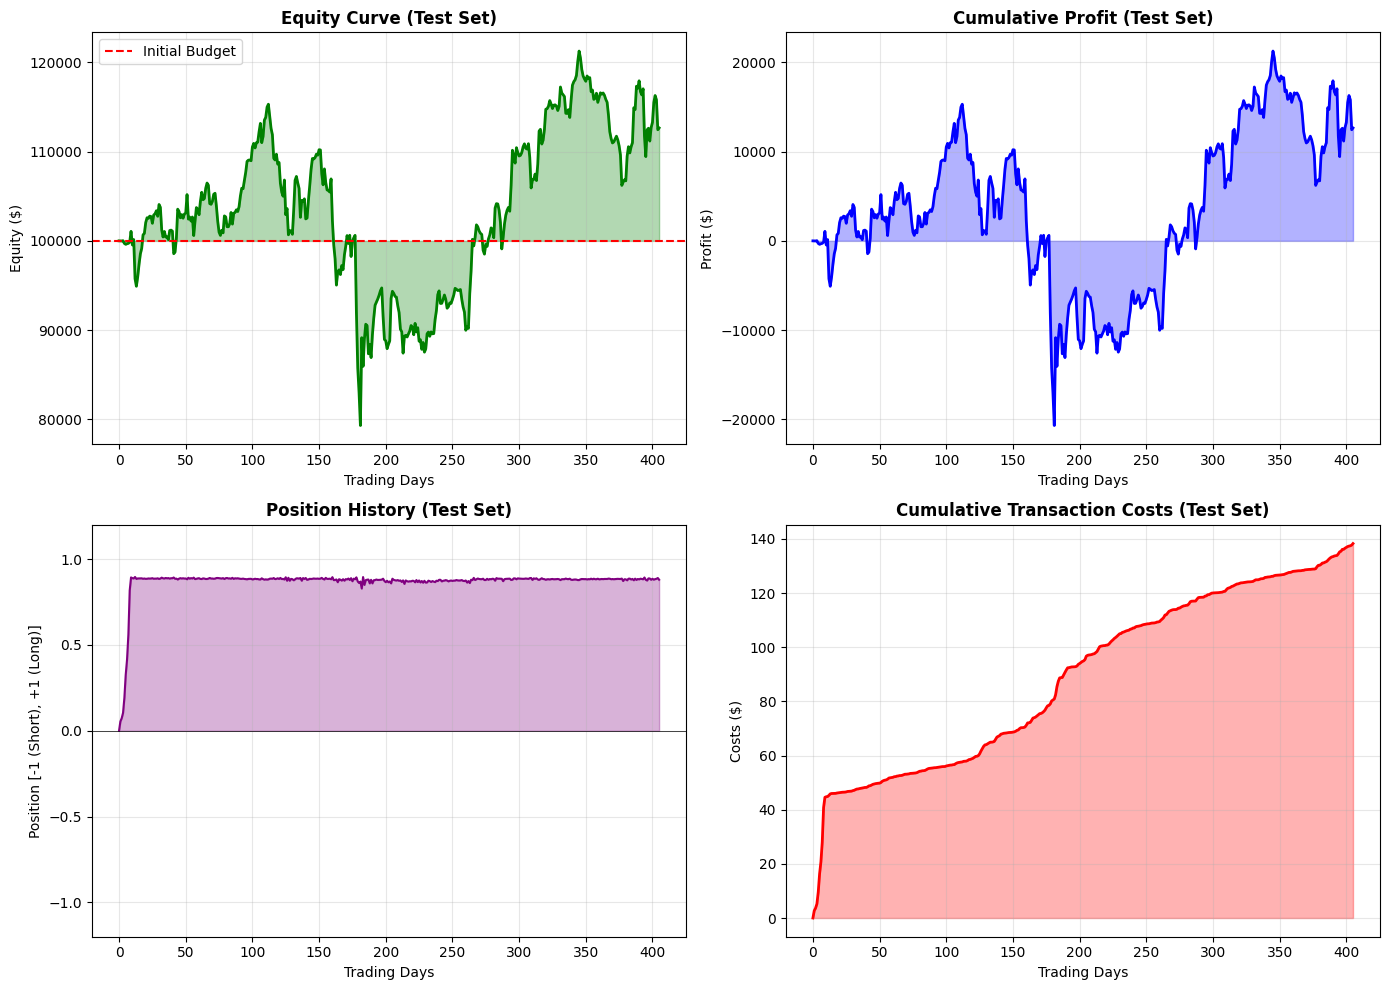

TRADING PERFORMANCE SUMMARY
Initial Budget: $100,000.00
Final Equity: $112,647.74
Total Profit: $12,647.74
Total Costs: $138.30
Return: 12.65%
Max Drawdown: 20.68%
Sharpe Ratio: 49.6303


In [12]:
def run_equity_curve(model, df_eval):
    env_eval = TradingEnv(df_eval, fee=FEE, kappa=KAPPA, initial_budget=INITIAL_BUDGET, max_leverage=2.0)
    obs, _ = env_eval.reset()
    done = False

    equity = [env_eval.equity]
    pos_hist = [env_eval.pos]
    profit_hist = [0.0]  # Track cumulative profit
    cost_hist = [0.0]    # Track cumulative costs

    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            dist, _ = model(obs_t)
            u = dist.mean
            a = squash(u).cpu().numpy()[0]

        obs, reward, terminated, truncated, info = env_eval.step(a)
        done = terminated or truncated
        equity.append(env_eval.equity)
        pos_hist.append(env_eval.pos)
        profit_hist.append(info["cumulative_profit"])
        cost_hist.append(info["costs"])

    return np.array(equity), np.array(pos_hist), np.array(profit_hist), np.array(cost_hist)

equity, pos_hist, profit_hist, cost_hist = run_equity_curve(model, df_test)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Equity Curve
axes[0, 0].plot(equity, linewidth=2, color='green')
axes[0, 0].fill_between(range(len(equity)), INITIAL_BUDGET, equity, alpha=0.3, color='green')
axes[0, 0].axhline(y=INITIAL_BUDGET, color='red', linestyle='--', label='Initial Budget')
axes[0, 0].set_title("Equity Curve (Test Set)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Trading Days")
axes[0, 0].set_ylabel("Equity ($)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Cumulative Profit
axes[0, 1].plot(profit_hist, linewidth=2, color='blue')
axes[0, 1].fill_between(range(len(profit_hist)), 0, profit_hist, alpha=0.3, color='blue')
axes[0, 1].set_title("Cumulative Profit (Test Set)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Trading Days")
axes[0, 1].set_ylabel("Profit ($)")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Position History
axes[1, 0].plot(pos_hist, linewidth=1.5, color='purple')
axes[1, 0].fill_between(range(len(pos_hist)), 0, pos_hist, alpha=0.3, color='purple')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_title("Position History (Test Set)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Trading Days")
axes[1, 0].set_ylabel("Position [-1 (Short), +1 (Long)]")
axes[1, 0].set_ylim([-1.2, 1.2])
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Costs
axes[1, 1].plot(cost_hist, linewidth=2, color='red')
axes[1, 1].fill_between(range(len(cost_hist)), 0, cost_hist, alpha=0.3, color='red')
axes[1, 1].set_title("Cumulative Transaction Costs (Test Set)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Trading Days")
axes[1, 1].set_ylabel("Costs ($)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Summary Statistics
print("=" * 60)
print("TRADING PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Initial Budget: ${INITIAL_BUDGET:,.2f}")
print(f"Final Equity: ${equity[-1]:,.2f}")
print(f"Total Profit: ${profit_hist[-1]:,.2f}")
print(f"Total Costs: ${cost_hist[-1]:,.2f}")
print(f"Return: {(equity[-1] - INITIAL_BUDGET) / INITIAL_BUDGET * 100:.2f}%")
print(f"Max Drawdown: {(1 - (equity.min() / INITIAL_BUDGET)) * 100:.2f}%")
print(f"Sharpe Ratio: {np.std(np.diff(equity)) / (np.mean(np.diff(equity)) + 1e-8) if np.mean(np.diff(equity)) != 0 else 0:.4f}")
print("=" * 60)
